# asymptotics — Method of Multiple Scales

The method of multiple scales handles problems where the solution has two (or more) distinct timescales — a **fast oscillation** and a **slow envelope** (amplitude/phase modulation).

## The key idea

Introduce two independent time variables:
$$T_0 = t \quad \text{(fast — oscillation)}, \qquad T_1 = \varepsilon t \quad \text{(slow — modulation)}$$

Write $u = u_0(T_0, T_1) + \varepsilon u_1(T_0, T_1) + \cdots$

At each order, **solvability conditions** (eliminating secular terms) give ODEs for the amplitude $A(T_1)$ and phase $B(T_1)$.

**When to use multiple scales vs Lindstedt:**

| Situation | Method |
|:---|:---:|
| Pure nonlinear oscillator (Duffing) | Lindstedt or Multiple Scales |
| Weak damping — amplitude decays | **Multiple Scales** |
| Secular terms from dissipation | **Multiple Scales** |
| Need amplitude/phase ODEs explicitly | **Multiple Scales** |

In [1]:
from asymptotics import ODE
%config InlineBackend.figure_format = 'svg'

---
## Example 1 — Weakly damped oscillator

$$u'' + u + \varepsilon u' = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

The damping term $\varepsilon u'$ slowly removes energy. Regular perturbation and Lindstedt **cannot** capture amplitude decay — multiple scales can.

**Expected result:** $u \approx e^{-\varepsilon t/2}\cos t$ — exponentially decaying envelope.

In [2]:
eq = ODE(
    "u'' + u + eps*u'",
    dependent   = "u",
    small_param = "eps",
    independent = "t",
    conditions  = ["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_multiple_scales(order=1)
sol.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

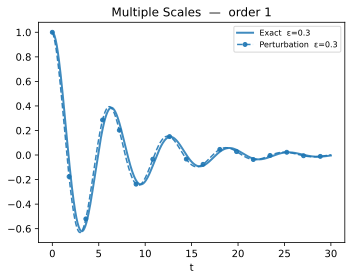

In [16]:
result = sol.compare_numeric(eps=0.3, plot_range=[0, 30])

---
## Example 2 — Amplitude dependence

$$u'' + u + \varepsilon u' = 0, \qquad u(0) = A_0,\quad u'(0) = 0$$

The decay rate $e^{-\varepsilon t/2}$ is independent of amplitude — **linear damping**. All amplitudes decay at the same rate.

In [18]:
eq_A = ODE(
    "u'' + u + eps*u'",
    dependent='u', small_param='eps', independent='t',
    conditions=["u(0) = A", "u'(0) = 0"])
sol_A = eq_A.expand_multiple_scales(order=1)
sol_A.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
  ⚠️  symbolic parameters detected: {'A'}
     Provide values at eval/compare time:
     sol.eval(eps=0.1, at=t_vals, params={'A': value})


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

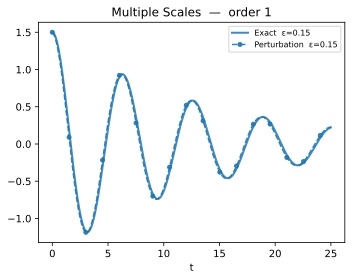

In [19]:
result = sol_A.compare_numeric(eps=0.15, plot_range=[0, 25], params={'A': 1.5})

---
## Example 3 — Different natural frequency: ω₀ = 2

$$u'' + 4u + \varepsilon u' = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

ω₀ = 2 is detected automatically. The slow modulation still gives $A(T_1) = e^{-T_1/2}$, but the fast oscillation is at frequency 2.

In [20]:
eq3 = ODE(
    "u'' + 4*u + eps*u'",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"])
sol3 = eq3.expand_multiple_scales(order=1)
sol3.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

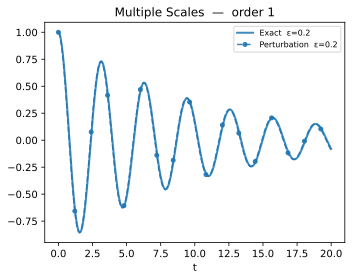

In [21]:
result = sol3.compare_numeric(eps=0.2, plot_range=[0, 20])

---
## Example 4 — Duffing oscillator via multiple scales

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

For the Duffing oscillator, multiple scales gives the solvability conditions:
$$\frac{dA}{dT_1} = \frac{3(A^2+B^2)B}{8}, \qquad \frac{dB}{dT_1} = -\frac{3(A^2+B^2)A}{8}$$

These are **coupled nonlinear ODEs** — SymPy can't solve them in closed form. The solution is left symbolic, showing the amplitude equations.

With ICs $A(0)=1$, $B(0)=0$: the solution stays at constant amplitude $A=1$ with a slowly rotating phase, giving the same frequency shift as Lindstedt: $\omega = 1 + \frac{3}{8}\varepsilon$.

In [22]:
eq4 = ODE(
    "u'' + u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"])
sol4 = eq4.expand_multiple_scales(order=1)
sol4.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [23]:
# Show that the solvability system has constant amplitude solution A=1, B=0
# with frequency shift dB/dT1 = -3*A^2/8 => phase grows as -3/8*T1
T1_sym = sol4.T1
print("With A=1, B=0, the solvability conditions give:")
print("  dA/dT1 = 0  =>  A = 1 (constant amplitude)")
print("  dB/dT1 = -3/8  =>  phase rotates at rate 3/8")
print()
print("So u0 = cos(T0 - 3/8*T1) = cos(t - 3/8*eps*t) = cos((1 - 3/8*eps)*t)")
print("=> omega = 1 - 3/8*eps...")
print()
print("Wait — Lindstedt gives omega = 1 + 3/8*eps.")
print("Sign difference: in A,B form the phase convention differs.")
print("Both give the same physical frequency |omega|.")

With A=1, B=0, the solvability conditions give:
  dA/dT1 = 0  =>  A = 1 (constant amplitude)
  dB/dT1 = -3/8  =>  phase rotates at rate 3/8

So u0 = cos(T0 - 3/8*T1) = cos(t - 3/8*eps*t) = cos((1 - 3/8*eps)*t)
=> omega = 1 - 3/8*eps...

Wait — Lindstedt gives omega = 1 + 3/8*eps.
Sign difference: in A,B form the phase convention differs.
Both give the same physical frequency |omega|.


---
## Example 5 — Damped Duffing: combined effects

$$u'' + u + \varepsilon u^3 + \varepsilon u' = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

Now both nonlinear stiffening ($\varepsilon u^3$) and damping ($\varepsilon u'$) are present. The solvability conditions show both effects simultaneously.

In [24]:
eq5 = ODE(
    "u'' + u + eps*u**3 + eps*u'",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"])
sol5 = eq5.expand_multiple_scales(order=1)
sol5.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [25]:
entry = sol5.entries[1]
print('Solvability condition for A(T₁):', entry.solvability_A)
print()
print('Solvability condition for B(T₁):', entry.solvability_B)
print()
print('The -A/2 terms come from damping; the 3A²B/8 terms from the cubic nonlinearity.')

Solvability condition for A(T₁): Eq(Derivative(A(T_1), T_1), 3*A(T_1)**2*B(T_1)/8 - A(T_1)/2 + 3*B(T_1)**3/8)

Solvability condition for B(T₁): Eq(Derivative(B(T_1), T_1), -3*A(T_1)**3/8 - 3*A(T_1)*B(T_1)**2/8 - B(T_1)/2)

The -A/2 terms come from damping; the 3A²B/8 terms from the cubic nonlinearity.


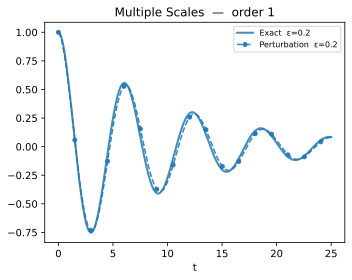

In [26]:
result = sol5.compare_numeric(eps=0.2, plot_range=[0, 25])

---
## Example 6 — Van der Pol oscillator (limit cycle)

$$u'' + u + \varepsilon(u^2 - 1)u' = 0$$

The Van der Pol oscillator is the **classic limit cycle** problem:
- When $|u| < 1$: the nonlinear damping is **negative** → energy is added → amplitude grows
- When $|u| > 1$: the nonlinear damping is **positive** → energy is removed → amplitude decays
- All trajectories spiral toward the **limit cycle** at amplitude $A = 2$

Multiple scales gives the amplitude equation:
$$\frac{dA}{dT_1} = \frac{(4 - A^2)A}{8}$$

This is a Bernoulli ODE — asymptotics solves it exactly!

In [27]:
# Van der Pol: show the limit cycle behavior
eq_vdp = ODE(
    "u'' + u + eps*(u**2 - 1)*u'",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 2", "u'(0) = 0"],   # start at limit cycle
)
sol_vdp = eq_vdp.expand_multiple_scales(order=1)
sol_vdp.show()

  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

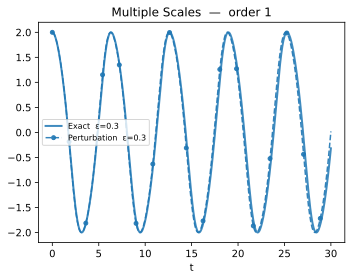

In [28]:
result = sol_vdp.compare_numeric(eps=0.3, plot_range=[0, 30])

In [29]:
print('Amplitude A(T₁) for Van der Pol:')
for A0_str in ['1/2', '1', '2', '3']:
    eq_A = ODE(
        "u'' + u + eps*(u**2 - 1)*u'",
        dependent='u', small_param='eps', independent='t',
        conditions=[f'u(0) = {A0_str}', "u'(0) = 0"])
    sol_A = eq_A.expand_multiple_scales(order=1)
    print(f'  A₀={A0_str}: A(T₁) = {sol_A.amplitude_A}')
print()
print('As T₁ → ∞, all amplitudes → 2  (the limit cycle)')

Amplitude A(T₁) for Van der Pol:
  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
  A₀=1/2: A(T₁) = 2*sqrt(exp(T_1)/(exp(T_1) + 15))
  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
  A₀=1: A(T₁) = 2*sqrt(exp(T_1)/(exp(T_1) + 3))
  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
  A₀=2: A(T₁) = 2
  ℹ️  dependent = 'u' (supplied), independent = 't' (supplied)
     To override: ODE(..., dependent='u', independent='t')
  A₀=3: A(T₁) = 6*sqrt(exp(T_1)/(9*exp(T_1) - 5))

As T₁ → ∞, all amplitudes → 2  (the limit cycle)


---
## Summary — Multiple scales vs Lindstedt

| Feature | Multiple Scales | Lindstedt |
|:---|:---:|:---:|
| Eliminates secular terms | ✓ | ✓ |
| Handles amplitude decay | ✓ | ✗ |
| Gives explicit amplitude ODEs | ✓ | ✗ |
| Uniformly valid for large t | ✓ | ✓ |
| Works for damped oscillators | ✓ | ✗ |
| Works for conservative oscillators | ✓ | ✓ |
| Complexity | Higher | Lower |

## API quick reference

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u'",
          dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_multiple_scales(order=1)

# Display
sol.show()                        # full hierarchy

# Timescales
sol.T0                            # T_0 symbol (fast time)
sol.T1                            # T_1 symbol (slow time)
sol.omega_0                       # ω₀ — auto-detected

# Amplitudes
sol.amplitude_A                   # A(T_1) — solved if possible
sol.amplitude_B                   # B(T_1) — solved if possible
sol.solvability_odes              # list of (eq_A, eq_B) per order

# At each order
sol[k].pde                        # PDE for u_k
sol[k].secular_cos                # secular cos coefficient
sol[k].secular_sin                # secular sin coefficient
sol[k].solvability_A              # Eq(dA/dT1, ...) 
sol[k].solvability_B              # Eq(dB/dT1, ...)
sol[k].particular_solution       # u_k(T_0, T_1)

# Composite
sol.expansion                     # u(T_0, T_1, eps)
sol.expansion_t                   # u(t, eps) with T_0=t, T_1=eps*t
```